# Simulating Bose-Einstein condensates - The Gross-Pitaevskii equation

This package is built on my previous package '[bloch_hamiltonian](https://github.com/GuillotMartin/bloch_schrodinger)'. It provides several solvers of the 2D [Gross-Pitaevskii](https://en.wikipedia.org/wiki/Gross%E2%80%93Pitaevskii_equation) equation. Two specialized solvers are meant to find the ground state of the time-independant Gross-Pitaevskii equation, while the main solver implements an adaptative split-step Fourier method (SSFM) to solve the time-depednant equation
$$\hat{H} \psi(\bf{r}) = \left[ -\frac{\hbar^2}{2m} \nabla^2 + V(\bf{r}) + g |\psi|^2 \right]  \psi(\bf{r}) = i \hbar \frac{\partial \psi}{\partial t}$$


### Ground state finder

Two solvers meant to find the ground state of a static Hamiltonian are implemented with the `GroundState` and `GroundStateSSFM` classes. They each use an [imaginary time evolution method](https://matterwavex.com/imaginary-time-evolution-method-for-finding-the-ground-state/). GroundState implements a [RKF45 adaptative method](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta%E2%80%93Fehlberg_method) and supports potential landscapes drawns by the 'Potential' class of the 'bloch_hamiltonian' package as well as multi-field equations and phase-shifted periodic boundary conditions. `GroundStateSSFM` is a much faster solver (especially for large grids) based on an adaptative SSFM method, but only works on scalar equations and rectangular grids. A future update to support multifields and non-rectangular grids might be developped at some time in the future.

### Time-Dependant solver

The main solver of this package is implemented in the `SSFM` class. It is able to solve the time-dependant problem using an adaptative SSFM method for periodic boundary conditions (and weakly absorbing boundary conditions).


In this tutorial, we will review its main methods `GroundStateSSFM` and `SSFM` and use them to observe the transition of a Bose-Einstein condensate from the ideal-gas to the [Thomas-Fermi](https://en.wikipedia.org/wiki/Thomas%E2%80%93Fermi_model) limit.

## Building a potential and initializing the solver

First, let's build an harmonic potential trap for our condensate.

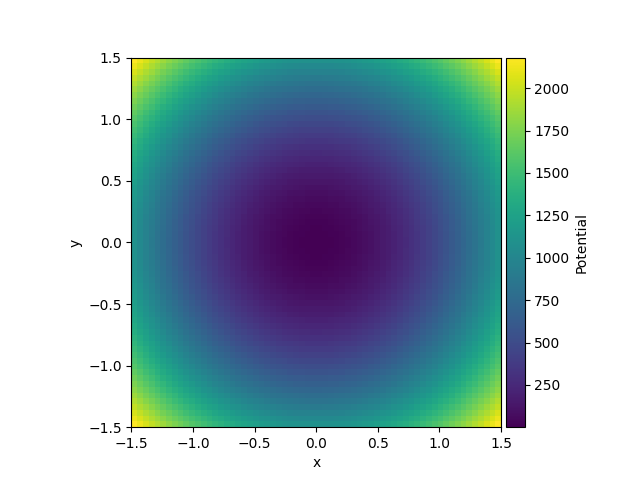

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from bloch_schrodinger.potential import Potential, create_parameter
from BECs.groundstate import GroundState
%matplotlib widget


# --- Instancing a flat potential ---
trap = Potential(
    unitvecs  =[[3,0],[0,3]],
    resolution = (64,64), # Fourier methods works best for powers of 2 discretizations
    v0 = 2250/2
)

# --- Shaping the potential ----
omega = 1000 # The harmonic trap strength ω

trap.set(
    value = (trap.x**2 + trap.y**2) * omega / 2 # The potential profile is a circularily symmetric harmonic trap
)

trap.plot()

# --- Instancing ---
# A single parameter will vary, the interaction strength g
g = create_parameter('g', np.linspace(0,0.5,6))

alpha = 1 # α = hbar²/2m = 1 as we set m and hbar equal to 1

ground = GroundState( # The Groundstate class is derived from the Solver class, and can be instanciated with: 
    potentials = trap, # a potential landscape
    alphas = alpha, # a kinetic term α
    gs = g # an interaction strength term g
)

Once the solver is instanced, one simply has to call the `solve` class method, specifying an atom population number for wavefunction normalization. Here, we take $N = 1000$. and parallelize the solver on 11 cores.

In [2]:

energies, groundstates = ground.solve(population = 1000) # A few other keyword arguments can be passed (see documentation).
# The solver is quite fast for such a small grid. For larger grid sizes, it supports easy parallelization for each set of parameters.

Computing the initial guesses


100%|██████████| 6/6 [00:00<00:00, 23.16it/s]


Computing the ground states


100%|██████████| 6/6 [00:00<00:00, 11.20it/s]


We can then plot the computed ground states using the plotting functions from the `bloch_schrodinger` package.

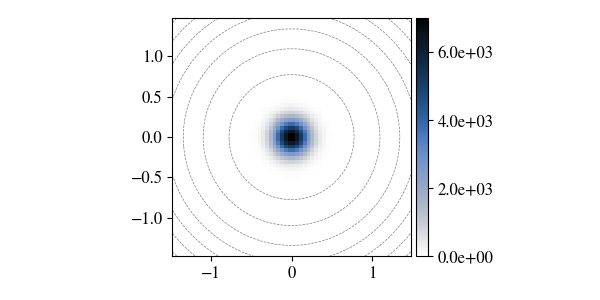

In [3]:
from bloch_schrodinger.plotting import plot_eigenvector, energy_levels
plot_eigenvector(
    [[abs(groundstates)**2]],
    [[trap]],
    [['amplitude']]
)
plt.show()

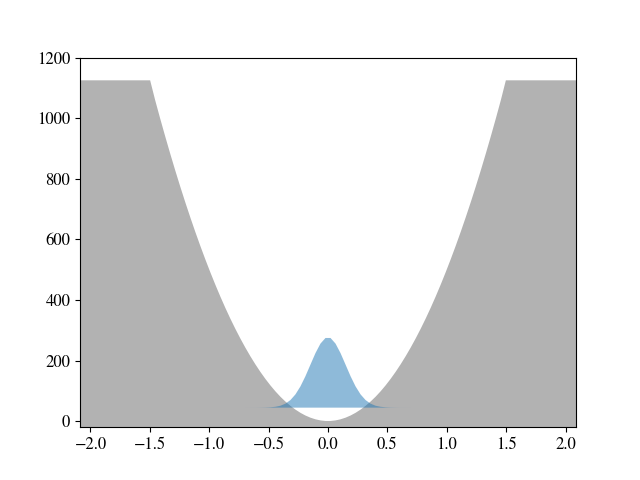

In [4]:
import matplotlib.pyplot as plt
density = abs(groundstates)**2

energy_levels(
    energies.expand_dims('band')/1000, #dividing by the population to get the energy/atom
    density.expand_dims('band') * energies, # rescaling by energy to take into account the spreading of the wavefunction and keep a constant profile height.
    trap,
    frac = 0.2,
    ymin = -20,
    ymax = 1200
)
plt.show()

With the energy_level function, we can clearly the two effects an increase in interaction strength has. First, the energy of the ground state increases due to the repulsive interactions, and secondly, the density profile of the ground state changes. In the Thomas-Fermi limit, the density profile $n(\bf{r})$ will actually match perfectly the shape of the potential:
$$n(\bf{r}) = \text{max} \left[ \frac{\mu - V(\bf{r})}{g} \right]$$
With $\mu$ the energy of the ground state, equal to the chemical potential. We can further highlight this by performing the same computation for a square well.

Computing the initial guesses


100%|██████████| 6/6 [00:00<00:00, 11.53it/s]
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:    5.6s remaining:    5.6s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:    5.9s finished


Reshaping and storing


100%|██████████| 6/6 [00:00<00:00, 258.79it/s]


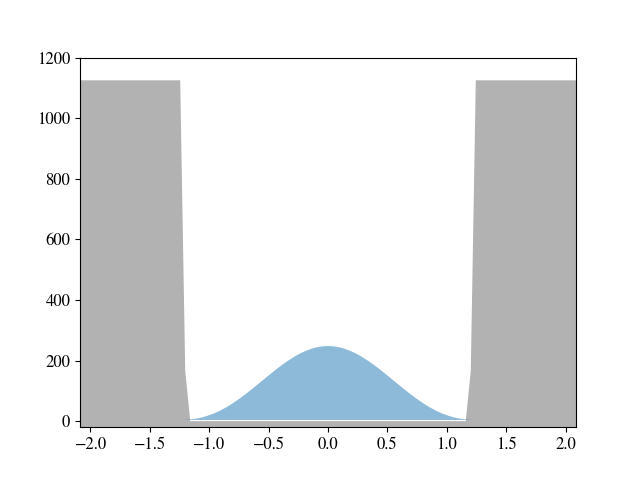

In [5]:
# --- Instancing a flat potential ---
square_trap = Potential(
    unitvecs  =[[3,0],[0,3]],
    resolution = (64,64),
    v0 = 2250/2
)

# --- Shaping the potential ----
square_trap.circle(
    center = (0,0),
    radius=1.2,
)


square_ground = GroundState(
    potentials = square_trap,
    alphas = alpha,
    gs = g
)

square_energies, square_groundstates = square_ground.solve(population = 1000, parallelize=True, n_cores = 6) 
square_density = abs(square_groundstates)**2

energy_levels(
    square_energies.expand_dims('band')/1000, #dividing by the population to get the energy/atom
    square_density.expand_dims('band'), # No rescaling here as the trap is square
    square_trap,
    frac = 0.2,
    ymin = -20,
    ymax = 1200
)
plt.show()

## Time-of-Flight simulation

One way to determine the regime of a condensate is to perform a time-of-flight experiment, which we can simulate with the `PotentialT` and `SSFM` classes. We are going to rebuild the initial harmonic trap for a much larger simulation area, then quickly switch it off, and see how the condensate spreads out from then. Because the grid is much larger, the `GroundState` class is not well suited for this computation, as it relies on a finite-difference method. We will instead go to a spectral split-step Fourier method, implemented in the `GroundStateSSFM` class, which is much faster, but limited to rectangular grids and scalar equations.

`PotentialT` is a child class of 'Potential' designed specifically for solving time-dependant problems. It allows the user to define custom time evolutions of specific features of a potential. A dedicated tutorial can be found [here](docs\potentialT.ipynb).

In [6]:
from BECs.potentialT import PotentialT
from BECs.groundstate import GroundStateSSFM

large_trap = PotentialT(
    unitvecs  =[[25,0],[0,25]], # Using a much larger simulation box
    resolution = (512,512), # Fourier methods works best for powers of 2 discretizations
    v0 = 0
)

# --- Shaping the potential ----
omega = 1000 # The harmonic trap strength ω

large_trap.add_shape( # The add_shape method adds a new shape to the potentialT object
    name = 'trap', 
    shape = (large_trap.x**2 + large_trap.y**2) * omega / 2
)

large_trap.step( # We add a time step function to switch off smoothly and quickly the potential. 
    "switch_off", ts = 0.05, sigma = 0.02, vi = 1, vf = 0
)

large_trap.add_term('trap * switch_off')


ground = GroundStateSSFM( # The GroundstateSSFM class is derived from the Solver class, and can be instanciated with: 
    potential = large_trap.to_potential(t = 0), # For the ground state, we use a static potential object V(t = 0).
    alpha = alpha, # a kinetic term α
    g = g # an interaction strength term g
)

energies, psi0 = ground.solve(population = 1000, parallelize=True, n_cores=6) 
# The initial vectors will be the ground state of the Harmonic trap. 
# This will take a minute because of the grid size

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:   52.2s remaining:   52.2s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:   53.7s finished


Reshaping and storing


100%|██████████| 6/6 [00:00<00:00, 820.78it/s]


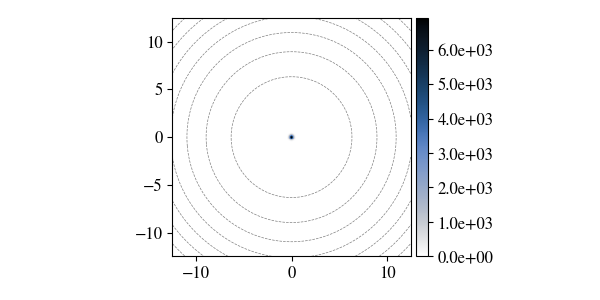

In [7]:
plot_eigenvector(
    [[abs(psi0)**2]],
    [[large_trap.to_potential(t = 0)]],
    [['amplitude']]
)
plt.show()

Let's look more closely at the PotentialT object. First, we have created a smooth step function to switch off the trap. We can look at its shape using the `plot_timefunction` class method.

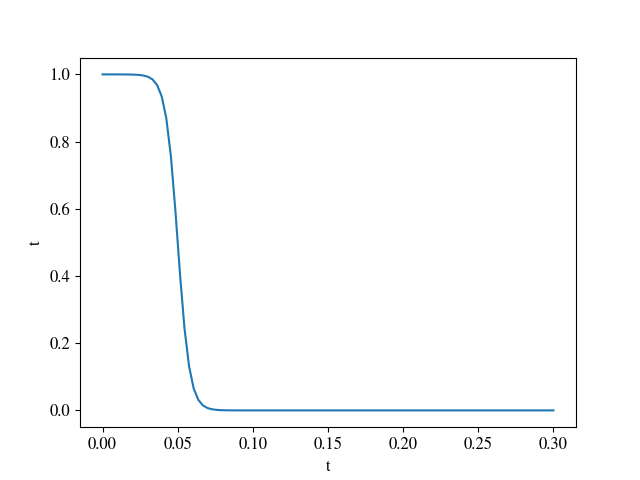

In [8]:
large_trap.plot_timefunction('switch_off', 0, 0.3) # plot_timefunction is interactive, as the parameters of the time function can be parameter dimensions.
plt.show()

We can also look at the whole potential using the `plot_t` class method.

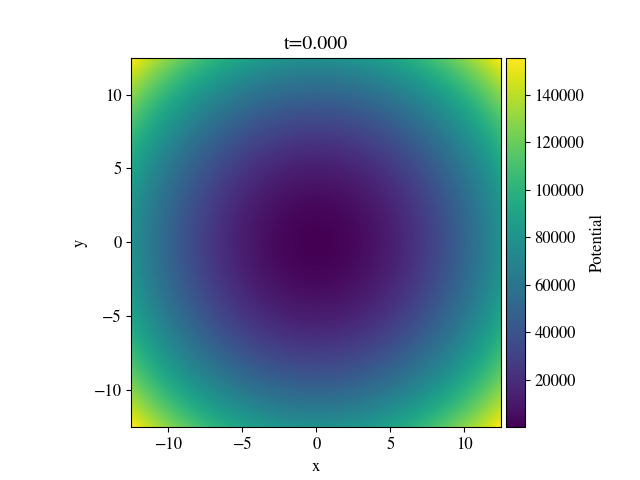

In [9]:

fig, ax = large_trap.plot_t(tmin = 0, tmax = 0.3)
plt.show()

Now that we have the initial condition and the time-dependant potential, we can call the `SSFM` solver, but first, we will have to specify the times at which we which to sample $\psi(t)$.

In [10]:
%reload_ext autoreload
%autoreload 2


from BECs.ssfm import SSFM
t_initial, t_final = 0, 0.3
t_samples = create_parameter('t', np.linspace(t_initial, t_final, 100)) # The sampling dimension must be called 't'.

time_evol = SSFM(
    potential   = large_trap,
    psi0        = psi0,
    alpha       = alpha,
    g           = g
)

time_evol.add_losses(0.15, 10) # we can add losses on the sides of the simulation box to limit reflections.

psi = time_evol.solve( # The solve function will propagate the initial vector psi0, taking care of broadcast to shape dimensions between the various arguments
    t_init      = t_initial,
    t_final     = t_final,
    t_samples   = t_samples,
    parallelize = True,
    verbose     = True,
    n_cores     = 6,
    tol = 1e-8 # larger tolerance to speed up the solver    
)

# The solver can take a few minutes to run, it could be GPU accelerated quite easily, but the original package prioritize system agnosticity.
# Some jobs are faster than other, this is often the case of large interaction. It might also be caused by numerical blow-up. Try to test 
# your simulation on few parameter points with the non-parallelized version first and the verbose option set to true. This will make a progress 
# bar appear and you will be able to see where the simulation is slowest.

[<function PotentialT.make_Vt.<locals>.Vt at 0x000001F20FACF3D0>, <function PotentialT.make_Vt.<locals>.Vt at 0x000001F20FACF690>, <function PotentialT.make_Vt.<locals>.Vt at 0x000001F20FACF950>, <function PotentialT.make_Vt.<locals>.Vt at 0x000001F20FACFC10>, <function PotentialT.make_Vt.<locals>.Vt at 0x000001F20FACFED0>, <function PotentialT.make_Vt.<locals>.Vt at 0x000001F20F868250>]
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  1.1min
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:  1.5min remaining:  3.0min
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:  1.6min remaining:  1.6min
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:  1.7min remaining:   50.3s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:  1.7min finished


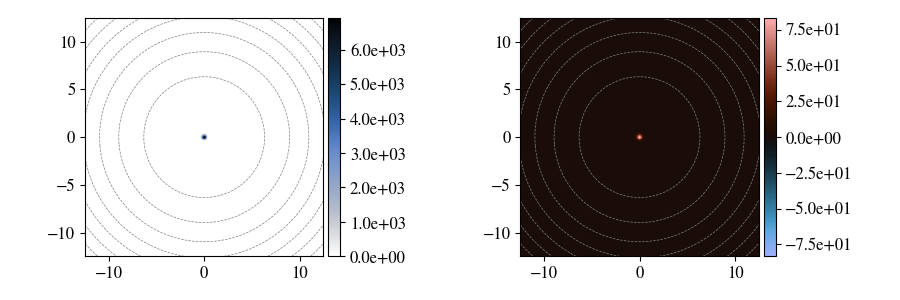

In [11]:
potential_array = large_trap.to_potential(t_coord = t_samples) # We can construct a regular potential to use in the plot_eigenvector function


plot_eigenvector(
    [[abs(psi)**2, psi.real]],
    [[potential_array, potential_array]],
    [['amplitude', 'real']]
)
plt.show()

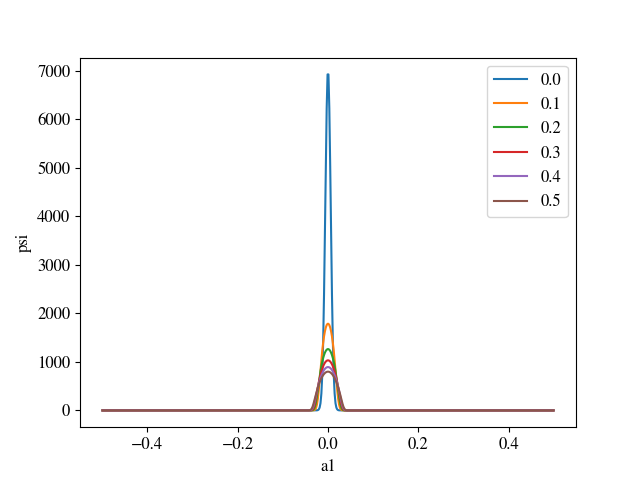

In [12]:
from bloch_schrodinger.plotting import plot_cuts
profile = (abs(psi)**2).sel(a2 = 0, method = 'nearest')# / (abs(psi.sel(t=0))**2).max(dim=['a1', 'a2'])

fig, ax = plot_cuts(
    profile,
    dim='a1',
    groupby=['g']
)
plt.legend([f"{g_val:.1f}" for g_val in profile.g.data])
plt.show()

What we can see is that the condensate, when released, perfectly keeps it shape. This means that thge shape of even a very small condensate can be studied in detail by simply releasing it and using classic absorption imaging techniques.